# NeqSim CO2 Impurity Kinetics: 100-Hour CSTR Multi-Phase Experiment Tutorial

This interactive notebook demonstrates how to use the high-level **`CO2ImpurityReactorExperiment`** class to set up, configure, and execute a 100-hour multi-phase **Continuous Stirred-Tank Reactor (CSTR)** experiment for impurity reactions in dense liquid $\text{CO}_2$ streams.

### Modular API Features:
1. **System & Vessel Charge Initialization**:
   - `exp = CO2ImpurityReactorExperiment(target_pressure_bar=25.0, target_temp_C=-25.0, diameter_cm=6.5, volume_ml=300.0, mass_flow_g_h=50.0)`
   - `exp.set_initial_vessel_charge(gas_name='N2', pressure_bar=1.0, temp_C=25.0)` (Default: $\text{N}_2$ at $1\text{ bar}, 25^\circ\text{C}$)
2. **Flexible Multi-Phase Addition**:
   - `exp.add_phase(duration_hours, feed_ppm, phase_name)` (Add as many custom phases as wanted!)
3. **Getter Methods & Automated Reporting**:
   - `exp.generate_reactor_report()` (Reactor geometry & residence time derivation)
   - `exp.get_table_results(resolution_hours=2.0)` (2-hour resolution master DataFrame)
4. **1-Line Plotting Helper**:
   - `exp.plot_results(save_path='cstr_100hr_experiment_plot.png')` (Effortless concentration plotting vs time).

> **Experimental model — calibration required.** Use these tutorials for research and teaching only; do not treat their parameters or results as validated design data.


In [1]:
import matplotlib.pyplot as plt
from neqsim_co2_kinetics import CO2ImpurityReactorExperiment

print("NeqSim CO2 Kinetic Engine & Experiment Manager Loaded!")


NeqSim CO2 Kinetic Engine & Experiment Manager Loaded!


## 1. System & Vessel Charge Initialization

We specify target pressure ($25\text{ bar}$), target temperature ($-25^\circ\text{C}$), reactor geometry ($D = 6.5\text{ cm}, V = 300\text{ mL}$), and mass flow rate ($50\text{ g/h}$).
The vessel initial charge defaults to $\text{N}_2$ gas at $1\text{ bar}, 25^\circ\text{C}$.

In [2]:
# Initialize SRK CO2 Experiment system
exp = CO2ImpurityReactorExperiment(
    target_pressure_bar=25.0,
    target_temp_C=-25.0,
    diameter_cm=6.50,
    volume_ml=300.0,
    mass_flow_g_h=50.0,
    material="carbon_steel",
)

# Specify initial vessel charge (Default: N2 at 1 bar, 25 °C if not specified)
exp.set_initial_vessel_charge(gas_name="N2", pressure_bar=1.0, temp_C=25.0)

print("Experiment System Initialized Successfully!")


Experiment System Initialized Successfully!


## 2. Automated Geometry & Hydrodynamic Residence Time Report

Calling `exp.generate_reactor_report()` automatically derives the reactor length $L$ and hydrodynamic residence time $\tau$.

In [3]:
# Print automated reactor derivation report
report = exp.generate_reactor_report()
print("=" * 100)
print(report)
print("=" * 100)


1. Reactor Geometry & Length (L) Derivation
Target Volume (V): 300.0 mL = 300.0 cm3 = 3.0e-04 m3
Inner Diameter (D): 6.50 cm = 0.0650 m
Cross-Sectional Area (A_cross): A_cross = pi * D^2 / 4 = pi * (6.50 cm)^2 / 4 = 33.1831 cm2 (3.31831e-03 m2)
Calculated Reactor Length (L): L = V / A_cross = 300.0 cm3 / 33.1831 cm2 = 9.0408 cm (0.090408 m)

2. Hydrodynamic Residence Time (tau) at 25.0 bar, -25.0°C
Fluid Density from NeqSim SRK EOS: Liquid CO2 density rho = 1057.72 kg/m3 (rho_m = 24.0339 kmol/m3).
Liquid Mass Inventory: m_reactor = 300.0 mL * 1.05772 g/mL = 317.32 grams of liquid CO2.
Mass Flow Rate (m_dot): 50.0 g/h.
CSTR Residence Time (tau): tau = m_reactor / m_dot = 317.32 g / 50.0 g/h = 6.3463 HOURS (22846.8 seconds)


## 3. Adding Experimental Phases for 100 Hours (add_phase)

We add 3 sequential phases for a total duration of 100 hours:
- **Phase 0 (10 h)**: Pure $\text{CO}_2$ Pressurization & Flow Out Constant Volume.
- **Phase 1 (40 h)**: $10\text{ ppm}$ feed **WITHOUT $\text{H}_2\text{S}$** ($0\text{ ppm }\text{H}_2\text{S}$).
- **Phase 2 (50 h)**: **ALL $10\text{ ppm}$ impurities INCLUDING $\text{H}_2\text{S}$**.

In [4]:
# Clear any existing phases
exp.clear_phases()

# Phase 0: Pure CO2 Pressurization & Flow Out (10 hours)
exp.add_phase(
    duration_hours=10.0,
    feed_ppm={"H2S": 0, "SO2": 0, "NO2": 0, "O2": 0, "H2O": 0},
    phase_name="Phase 0: Pure CO2 Pressurization",
)

# Phase 1: 10 ppm Feed WITHOUT H2S (40 hours)
exp.add_phase(
    duration_hours=40.0,
    feed_ppm={"SO2": 10, "NO2": 10, "O2": 10, "H2O": 10},
    phase_name="Phase 1: 10 ppm Without H2S (40h)",
)

# Phase 2: 10 ppm Feed WITH ALL IMPURITIES (50 hours)
exp.add_phase(
    duration_hours=50.0,
    feed_ppm={"H2S": 10, "SO2": 10, "NO2": 10, "O2": 10, "H2O": 10},
    phase_name="Phase 2: 10 ppm All Impurities (50h)",
)

# Run experiment across all phases
sim_res = exp.run_experiment()
print("100-Hour Multi-Phase Experiment Run Successfully Completed!")


100-Hour Multi-Phase Experiment Run Successfully Completed!


## 4. Master Concentration Table (0 to 100 h at 2-Hour Resolution)

We call `exp.get_table_results(resolution_hours=2.0)` to generate the master concentration table at 2-hour intervals from $0.0$ to $100.0\text{ hours}$.

In [5]:
# Get master 2-hour resolution table (0 to 100 h)
df_results_100h = exp.get_table_results(resolution_hours=2.0)

print("=" * 110)
print("MASTER 100-HOUR EXPERIMENT CONCENTRATION TABLE (2-HOUR RESOLUTION)")
print("=" * 110)
df_results_100h


MASTER 100-HOUR EXPERIMENT CONCENTRATION TABLE (2-HOUR RESOLUTION)
Out[0]: 
    Time (h)  H2S (ppm)  SO2 (ppm)  ...  HNO3 (ppm)  NH3 (ppm)  S8 (ppm)
0        0.0       0.00       0.00  ...         0.0     0.0000    0.0000
1        2.0       0.00       0.00  ...         0.0     0.0000    0.0000
2        4.0       0.00       0.00  ...         0.0     0.0000    0.0000
3        6.0       0.00       0.00  ...         0.0     0.0000    0.0000
4        8.0       0.00       0.00  ...         0.0     0.0000    0.0000
5       10.0       0.00       0.00  ...         0.0     0.0000    0.0000
6       12.0       0.00       2.71  ...         0.0     0.0000    0.0000
7       14.0       0.00       4.68  ...         0.0     0.0000    0.0000
8       16.0       0.00       6.12  ...         0.0     0.0000    0.0000
9       18.0       0.00       7.17  ...         0.0     0.0000    0.0000
10      20.0       0.00       7.93  ...         0.0     0.0000    0.0000
11      22.0       0.00       8.48  ...         

## 5. Effortless 1-Line Plotting vs Time

We call `exp.plot_results()` to generate a publication-quality 3-panel plot showing reactants consumption and products formation over the full 100-hour timeline.

Plot saved successfully to: cstr_100hr_experiment_plot.png


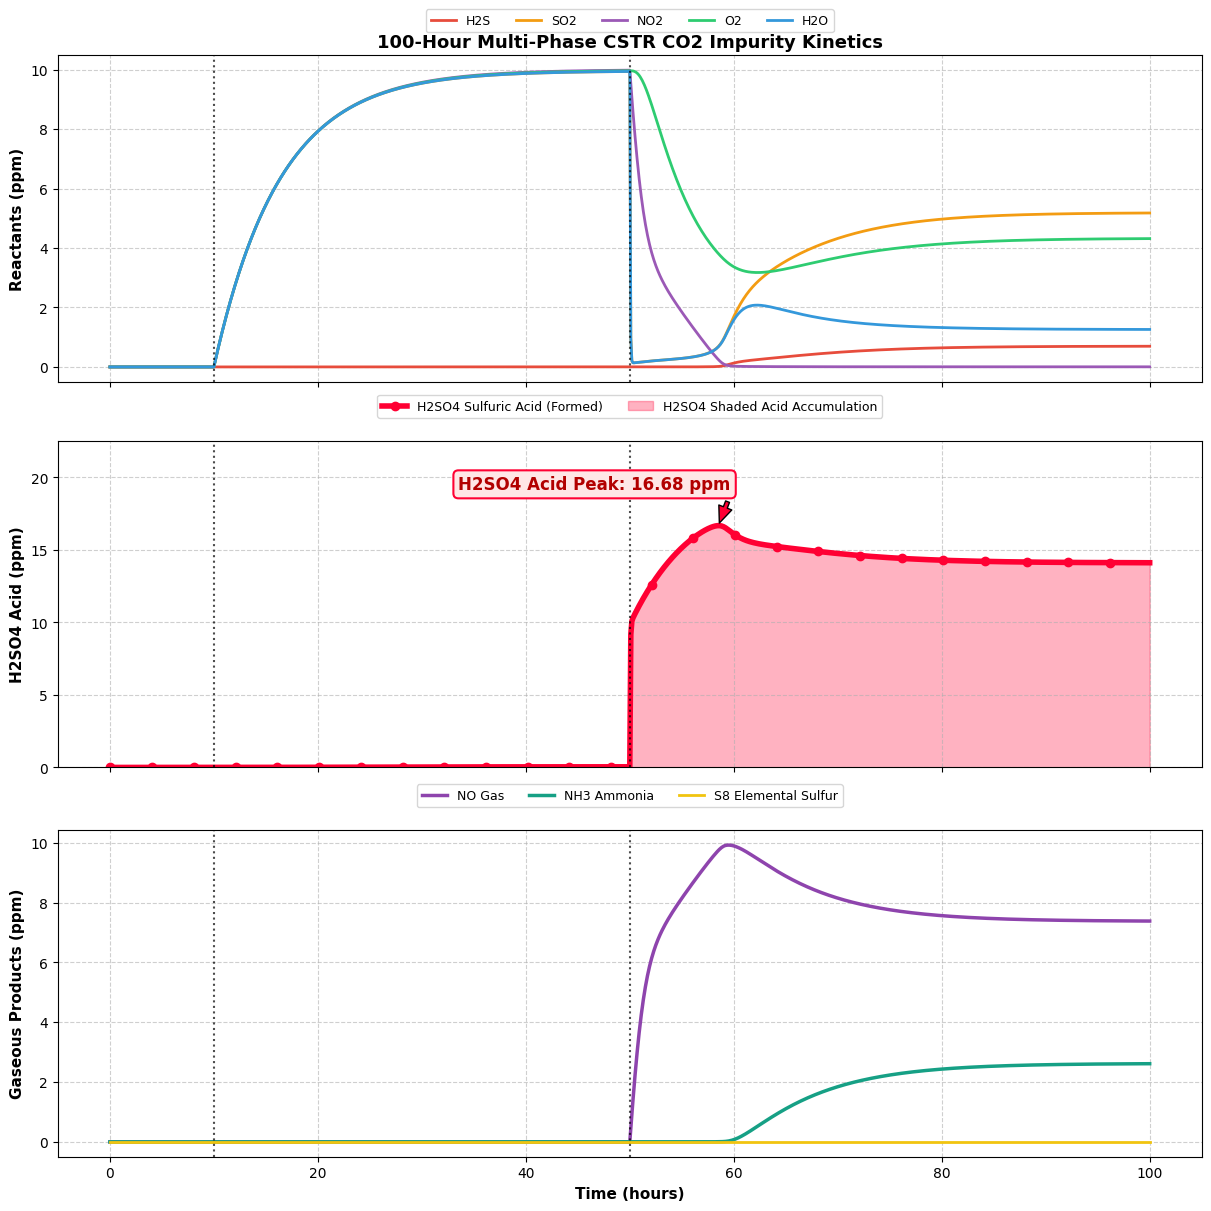

In [6]:
# 1-Line Plotting Helper
exp.plot_results(
    save_path="cstr_100hr_experiment_plot.png",
    title="100-Hour Multi-Phase CSTR CO2 Impurity Kinetics",
)
plt.show()
